In [1]:
#@title env
!pip install kagglehub opencv-python

import kagglehub
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [2]:
#@title download datset
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")
print("Path:", path)
print("Isi:", os.listdir(path))

100%|██████████| 398M/398M [00:08<00:00, 50.3MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1
Isi: ['annotations', 'images']


In [3]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


In [4]:
#@title set path
image_dir = os.path.join(path, "images")
ann_dir = os.path.join(path, "annotations")

print(os.listdir(image_dir)[:5])
print(os.listdir(ann_dir)[:5])

['maksssksksss791.png', 'maksssksksss183.png', 'maksssksksss551.png', 'maksssksksss210.png', 'maksssksksss744.png']
['maksssksksss771.xml', 'maksssksksss127.xml', 'maksssksksss549.xml', 'maksssksksss754.xml', 'maksssksksss395.xml']


In [5]:
#@title crop 500 waajh
os.makedirs("dataset/with_mask", exist_ok=True)
os.makedirs("dataset/without_mask", exist_ok=True)

count = 0
LIMIT = 500

for file in os.listdir(ann_dir):
    if count >= LIMIT:
        break

    tree = ET.parse(os.path.join(ann_dir, file))
    root = tree.getroot()

    img_name = root.find('filename').text
    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    for obj in root.findall('object'):
        if count >= LIMIT:
            break

        label = obj.find('name').text.lower()

        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        face = img[ymin:ymax, xmin:xmax]

        if face.size == 0:
            continue

        face = cv2.resize(face, (224, 224))

        # mapping label
        if "with_mask" in label:
            folder = "with_mask"
        else:
            folder = "without_mask"

        cv2.imwrite(f"dataset/{folder}/{count}.jpg", face)
        count += 1

print("Total data:", count)

Total data: 500


In [6]:
#@title data generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "dataset",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "dataset",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 401 images belonging to 2 classes.
Found 99 images belonging to 2 classes.


In [7]:
#@title model mobilenet
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=x)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
#@title train 5 epoch
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 837ms/step - accuracy: 0.8229 - loss: 0.4233 - val_accuracy: 0.8586 - val_loss: 0.3123
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 711ms/step - accuracy: 0.8678 - loss: 0.2987 - val_accuracy: 0.8687 - val_loss: 0.2875
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 778ms/step - accuracy: 0.8853 - loss: 0.2709 - val_accuracy: 0.8283 - val_loss: 0.3301
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 697ms/step - accuracy: 0.8853 - loss: 0.2565 - val_accuracy: 0.8283 - val_loss: 0.3176
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 790ms/step - accuracy: 0.9102 - loss: 0.2316 - val_accuracy: 0.8687 - val_loss: 0.2839


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# reset generator
val_data.reset()

# prediksi
pred = model.predict(val_data, verbose=1)

# label
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes
class_labels = list(val_data.class_indices.keys())

# REPORT
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

print("===== HASIL EVALUASI (PERSEN) =====\n")

for label in class_labels:
    print(f"Kelas: {label}")
    print(f"  Precision : {report[label]['precision']*100:.2f}%")
    print(f"  Recall    : {report[label]['recall']*100:.2f}%")
    print(f"  F1-Score  : {report[label]['f1-score']*100:.2f}%\n")

print(f"Akurasi Total : {report['accuracy']*100:.2f}%\n")

print("Macro Avg:")
print(f"  Precision : {report['macro avg']['precision']*100:.2f}%")
print(f"  Recall    : {report['macro avg']['recall']*100:.2f}%")
print(f"  F1-Score  : {report['macro avg']['f1-score']*100:.2f}%\n")

print("Weighted Avg:")
print(f"  Precision : {report['weighted avg']['precision']*100:.2f}%")
print(f"  Recall    : {report['weighted avg']['recall']*100:.2f}%")
print(f"  F1-Score  : {report['weighted avg']['f1-score']*100:.2f}%\n")

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
===== HASIL EVALUASI (PERSEN) =====

Kelas: with_mask
  Precision : 83.15%
  Recall    : 90.24%
  F1-Score  : 86.55%

Kelas: without_mask
  Precision : 20.00%
  Recall    : 11.76%
  F1-Score  : 14.81%

Akurasi Total : 76.77%

Macro Avg:
  Precision : 51.57%
  Recall    : 51.00%
  F1-Score  : 50.68%

Weighted Avg:
  Precision : 72.30%
  Recall    : 76.77%
  F1-Score  : 74.23%

Confusion Matrix:
 [[74  8]
 [15  2]]


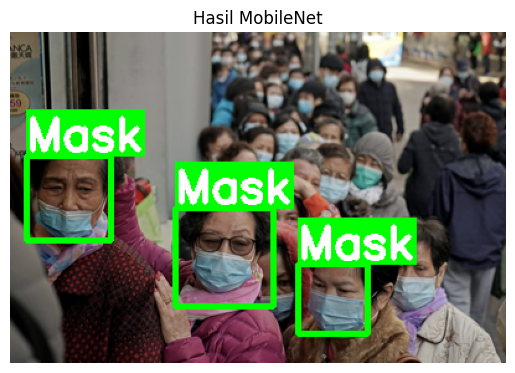

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

img_path = "maksssksksss11.png"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

box_thickness = 4
font_scale = 1.2
font_thickness = 3

for (x, y, w, h) in faces:
    face = img_rgb[y:y+h, x:x+w]

    if face.size == 0:
        continue

    face = cv2.resize(face, (224,224))
    face = face / 255.0
    face = np.expand_dims(face, axis=0)

    pred = model.predict(face, verbose=0)
    label = np.argmax(pred)

    if label == 0:
        text = "Mask"
        color = (0,255,0)
    else:
        text = "No Mask"
        color = (255,0,0)

    cv2.rectangle(img_rgb, (x,y), (x+w,y+h), color, box_thickness)

    (text_w, text_h), _ = cv2.getTextSize(
        text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness
    )
    cv2.rectangle(img_rgb, (x, y - text_h - 10), (x + text_w, y), color, -1)

    cv2.putText(
        img_rgb, text, (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX, font_scale,
        (255,255,255), font_thickness
    )

plt.imshow(img_rgb)
plt.title("Hasil MobileNet")
plt.axis('off')
plt.show()